# Разработка A/B-тестирования и анализ результатов
- Автор: Алферова Полина 
- Дата: 11.12.2025

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import scipy.stats as stats

In [4]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [5]:
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [6]:
# Количество уникальных сессий для каждого пользователя
user_sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
user_sessions_count.rename(columns={'session_id': 'unique_sessions_count'}, inplace=True)

In [7]:
# Пользователь с наибольшим количеством уникальных сессий
max_sessions = user_sessions_count['unique_sessions_count'].max()
top_user_id = user_sessions_count[user_sessions_count['unique_sessions_count'] == max_sessions]['user_id'].iloc[0]

In [8]:
# Все строки для этого пользователя
top_user_data = sessions_history[sessions_history['user_id'] == top_user_id]
display(top_user_data)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Пользователь совершил 10 сессий с 2025-08-14 по 2025-08-25 на Android в регионе CIS, при этом регистрация не была совершена. В каждой сессии он просматривал от 1 до 4 страниц, что указывает на умеренную вовлечённость, с несколькими сессиями, где просмотрено ≥4 страниц, что потенциально говорит о высокой заинтересованности. Активность распределена неравномерно с пропусками дней между сессиями.

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [9]:
# Число уникальных пользователей и число зарегистрированных пользователей по дням
daily_stats = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')
).reset_index()

In [10]:
# Доля зарегистрированных пользователей
daily_stats['registered_ratio'] = daily_stats['registered_users'] / daily_stats['total_users']

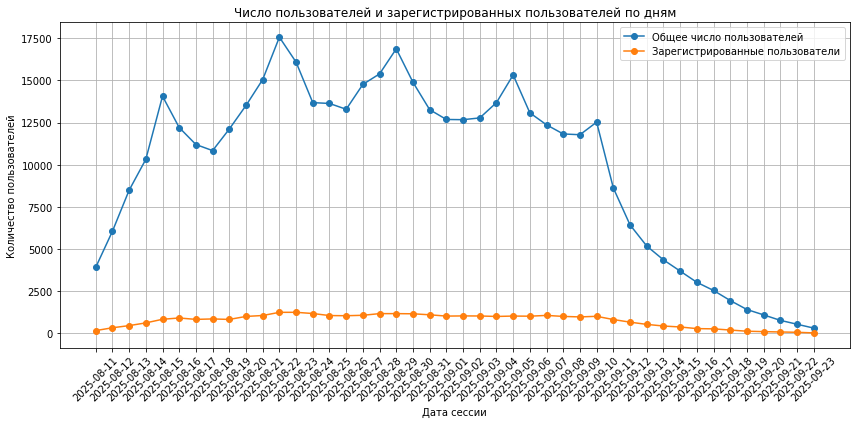

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Общее число пользователей', marker='o')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные пользователи', marker='o')
plt.title('Число пользователей и зарегистрированных пользователей по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

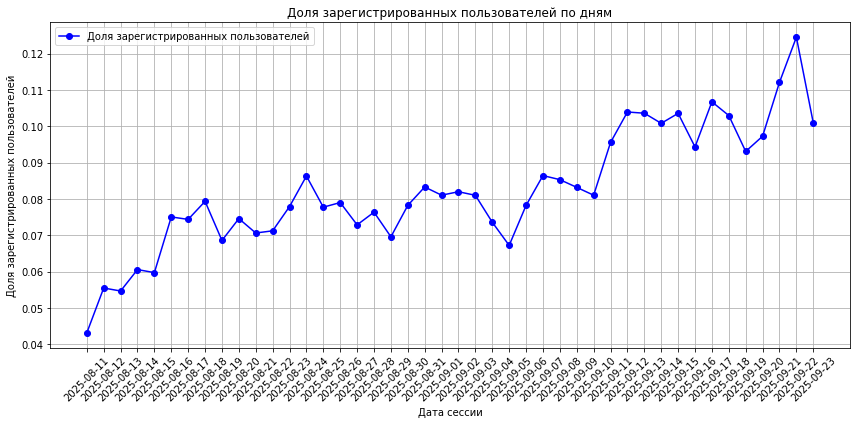

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(daily_stats['session_date'], daily_stats['registered_ratio'], label='Доля зарегистрированных пользователей', color='blue', marker='o')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля зарегистрированных пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
daily_summary = daily_stats[['session_date', 'total_users', 'registered_users']].copy()

daily_summary['registered_ratio'] = daily_summary['registered_users'] / daily_summary['total_users']

display(daily_summary)

,session_date,total_users,registered_users,registered_ratio
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723
5,2025-08-16,12205,916,0.075051
6,2025-08-17,11200,833,0.074375
7,2025-08-18,10839,860,0.079343
8,2025-08-19,12118,831,0.068576
9,2025-08-20,13514,1008,0.074589


Анализ исторических данных показал, что общее число пользователей в день варьировалось от 317 до 17 563. Доля зарегистрированных пользователей от всех пользователей постепенно увеличивалась. На большинстве дней абсолютное число зарегистрированных пользователей составляло от 32 до 1 251. В целом, большинство пользователей остаётся незарегистрированными, но наблюдается стабильный рост вовлечённых регистраций.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [14]:
# Количество сессий для каждого значения
page_counts = sessions_history['page_counter'].value_counts().sort_index().reset_index()
page_counts.columns = ['page_counter', 'sessions_count']

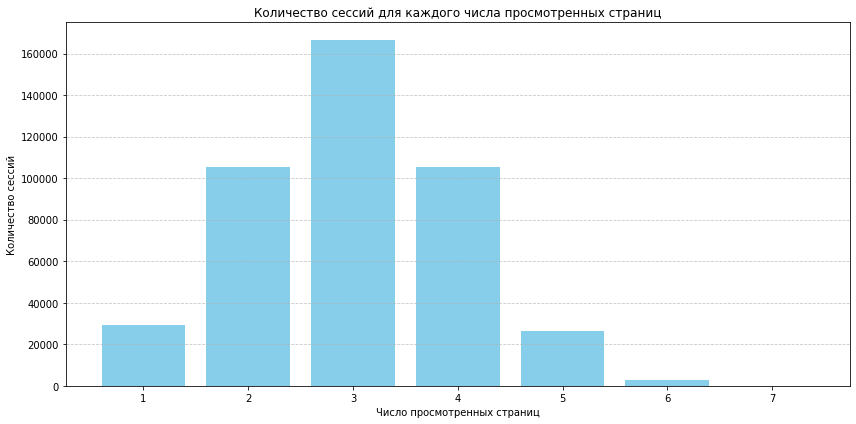

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(page_counts['page_counter'], page_counts['sessions_count'], color='skyblue')
plt.title('Количество сессий для каждого числа просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.xticks(page_counts['page_counter'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
page_counts['sessions_ratio'] = page_counts['sessions_count'] / page_counts['sessions_count'].sum()

display(page_counts)

,page_counter,sessions_count,sessions_ratio
0,1,29160,0.066892
1,2,105536,0.242097
2,3,166690,0.382383
3,4,105569,0.242173
4,5,26288,0.060304
5,6,2589,0.005939
6,7,92,0.000211


В масштабах всей базы пользователей распределение просмотров страниц:

3 страницы — 166 690 сессий (38,2%),

2 страницы — 105 536 сессий (24,2%),

4 страницы — 105 569 сессий (24,2%),

1 страница — 29 160 сессий (6,7%),

5 и более страниц — менее 7% всех сессий.

Таким образом, большинство пользователей просматривают 2–4 страницы за сессию, высоко вовлечённые сессии (5 и более страниц) встречаются редко, а полностью минимальные сессии (1 страница) составляют меньшую часть. Данные по отдельным активным пользователям подтверждают общую картину умеренной вовлечённости с разнообразием количества просмотров страниц.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [17]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

daily_good_ratio = sessions_history.groupby('session_date')['good_session'].mean().reset_index()

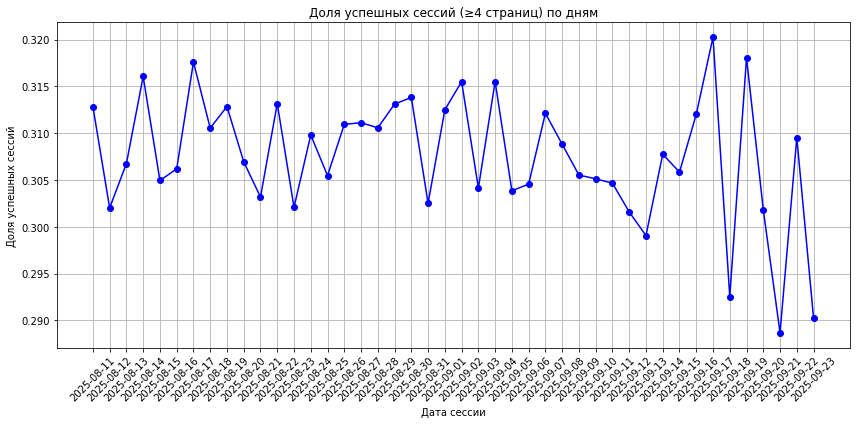

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(daily_good_ratio['session_date'], daily_good_ratio['good_session'], marker='o', color='blue')
plt.title('Доля успешных сессий (≥4 страниц) по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля успешных сессий')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
daily_sessions = sessions_history.groupby('session_date').agg(
    total_sessions=('session_id', 'nunique'),        
    good_sessions=('good_session', 'sum')           
).reset_index()

daily_sessions['good_sessions_ratio'] = daily_sessions['good_sessions'] / daily_sessions['total_sessions']

display(daily_sessions)

,session_date,total_sessions,good_sessions,good_sessions_ratio
0,2025-08-11,3919,1226,0.312835
1,2025-08-12,6056,1829,0.302015
2,2025-08-13,8489,2604,0.306750
3,2025-08-14,10321,3262,0.316055
4,2025-08-15,14065,4289,0.304941
5,2025-08-16,12205,3737,0.306186
6,2025-08-17,11200,3557,0.317589
7,2025-08-18,10839,3366,0.310545
8,2025-08-19,12118,3791,0.312840
9,2025-08-20,13514,4148,0.306941


Активность пользователей: число уникальных пользователей колебалось от 317 до 17 563 в день; один из самых активных пользователей совершил до 10 сессий за период.

Регистрации: ежедневное число зарегистрированных пользователей варьировалось от 32 до 5 500, доля зарегистрированных пользователей — от 4,3% до 12,5%, в среднем около 7–8%.

Просмотренные страницы: большинство сессий ограничивались 2–4 страницами (2 страницы — 105 536 сессий, 3 страницы — 166 690, 4 страницы — 105 569). Сессии с более чем 6 страницами встречались редко.

Вовлечённость пользователей: сессии с ≥4 просмотренными страницами составляли примерно 30–32% от всех сессий (например, 2025-08-11 — 1 226 из 3 919 сессий, 31,3%).

Активность пользователей и число регистраций демонстрируют стабильную динамику, а треть сессий с большим числом просмотров указывает на достаточный уровень вовлечённости. Эти данные дают надежную основу для дальнейшего анализа и проведения A/B-тестов.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

Сформулируйте нулевую и альтернативную гипотезы:






В рамках A/B-теста в качестве ключевой продуктовой метрики была выбрана доля успешных сессий, где успешной считается сессия с 4 и более просмотренными страницами. Эта метрика напрямую связана с удовлетворённостью контентом и работой рекомендательного алгоритма.

Нулевая гипотеза: внедрение нового алгоритма рекомендаций не изменяет долю успешных сессий — значения метрики в контрольной и тестовой группах статистически не различаются.

Альтернативная гипотеза: новый алгоритм рекомендаций повышает долю успешных сессий в тестовой группе по сравнению с контрольной.

Таким образом, результат A/B-теста оценивается по наличию статистически значимого роста доли успешных сессий после внедрения нового алгоритма.

#### 2.2. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [20]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05        # уровень значимости
beta = 0.2          # вероятность ошибки второго рода
power = 1 - beta    # мощность теста
p = 0.3             # базовый уровень доли
mde = 0.03 * p      # MDE = 3% от базового уровня

# effect size для долей
effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")


Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [21]:
from math import ceil

# Загружаем исторические данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# Считаем уникальных пользователей по дням
daily_users = (
    sessions_history
    .groupby('session_date')['user_id']
    .nunique()
)
# Среднее количество уникальных пользователей в день
avg_daily_users = daily_users.mean()
print(f"Среднее количество пользователей в день: {avg_daily_users:.0f}")

# Размер выборки
total_users_needed = sample_size * 2

# Длительность теста
test_duration = ceil(total_users_needed / avg_daily_users)

print(
    f"Рассчитанная длительность A/B-теста при текущем уровне трафика "
    f"в {avg_daily_users:.0f} пользователей в день составит {test_duration} дней"
)

Среднее количество пользователей в день: 9907
Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


Планируемый A/B-тест имеет чётко определённую цель — оценить изменение доли успешных сессий после внедрения нового алгоритма. С учётом размера выборки (по 41 040 пользователей на группу) и предполагаемого уровня трафика (9 907 пользователей в день), тест можно провести за 9 дней, что является достаточно быстрым сроком для получения статистически значимых результатов.

Таким образом, тест обеспечит надёжную проверку гипотезы о повышении вовлечённости пользователей и позволит принять обоснованное решение о внедрении нового алгоритма рекомендаций.

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [22]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [23]:
# Уникальные пользователи в каждой группе
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index()
users_per_group.rename(columns={'user_id': 'unique_users'}, inplace=True)
display(users_per_group)

,test_group,unique_users
0,A,1477
1,B,1466


In [24]:
A = users_per_group.loc[users_per_group['test_group'] == 'A', 'unique_users'].values[0]
B = users_per_group.loc[users_per_group['test_group'] == 'B', 'unique_users'].values[0]

percent_diff = 100 * abs(A - B) / A
print(f'Процентная разница в количестве пользователей между группами: {percent_diff:.2f}%')

Процентная разница в количестве пользователей между группами: 0.74%


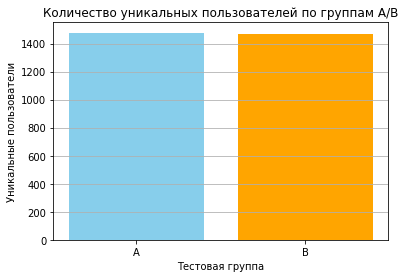

In [25]:
plt.figure(figsize=(6, 4))
plt.bar(users_per_group['test_group'], users_per_group['unique_users'], color=['skyblue', 'orange'])
plt.title('Количество уникальных пользователей по группам A/B')
plt.ylabel('Уникальные пользователи')
plt.xlabel('Тестовая группа')
plt.grid(axis='y')
plt.show()

Распределение пользователей между группами A и B сбалансировано: разница всего 0,74%, что подтверждает корректность рандомизации.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [26]:
users_a = set(sessions_test_part[sessions_test_part.test_group == 'A']['user_id'])
users_b = set(sessions_test_part[sessions_test_part.test_group == 'B']['user_id'])

overlap_users = users_a.intersection(users_b)
num_overlap = len(overlap_users)

print(f"Количество пользователей, попавших в обе группы: {num_overlap}")

Количество пользователей, попавших в обе группы: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [27]:
# Доля пользователей по устройствам для каждой группы
device_dist = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index()
device_dist['device_ratio'] = device_dist.groupby('test_group')['user_id'].transform(lambda x: x / x.sum())

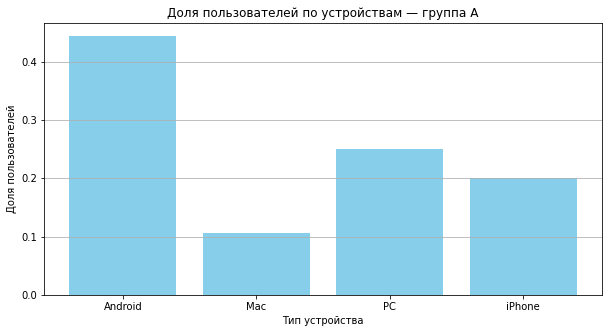

In [28]:
plt.figure(figsize=(10, 5))
a_dist = device_dist[device_dist['test_group'] == 'A']
plt.bar(a_dist['device'], a_dist['device_ratio'], color='skyblue')
plt.title('Доля пользователей по устройствам — группа A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(axis='y')
plt.show()

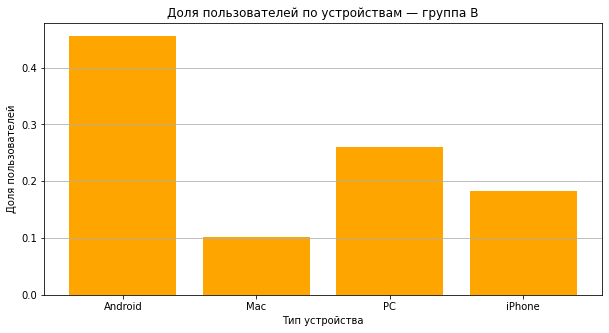

In [29]:
plt.figure(figsize=(10, 5))
b_dist = device_dist[device_dist['test_group'] == 'B']
plt.bar(b_dist['device'], b_dist['device_ratio'], color='orange')
plt.title('Доля пользователей по устройствам — группа B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(axis='y')
plt.show()

In [30]:
device_stats = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index()
device_stats.rename(columns={'user_id': 'users_count'}, inplace=True)

device_stats['users_ratio'] = device_stats.groupby('test_group')['users_count'].apply(lambda x: x / x.sum())

display(device_stats)

,test_group,device,users_count,users_ratio
0,A,Android,656,0.444144
1,A,Mac,156,0.105619
2,A,PC,369,0.249831
3,A,iPhone,296,0.200406
4,B,Android,668,0.455662
5,B,Mac,148,0.100955
6,B,PC,381,0.259891
7,B,iPhone,269,0.183492


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


In [31]:
region_dist = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index()
region_dist['region_ratio'] = region_dist.groupby('test_group')['user_id'].transform(lambda x: x / x.sum())

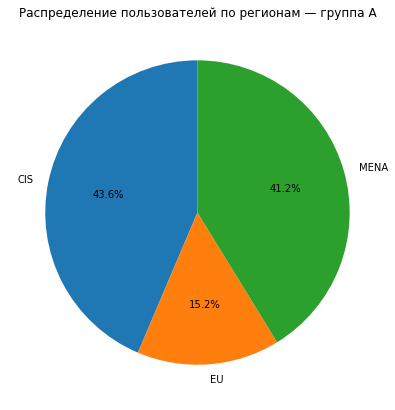

In [32]:
region_a = region_dist[region_dist['test_group'] == 'A']
plt.figure(figsize=(7, 7))
plt.pie(
    region_a['region_ratio'], 
    labels=region_a['region'], 
    autopct='%1.1f%%', 
    startangle=90
)
plt.title('Распределение пользователей по регионам — группа A')
plt.show()

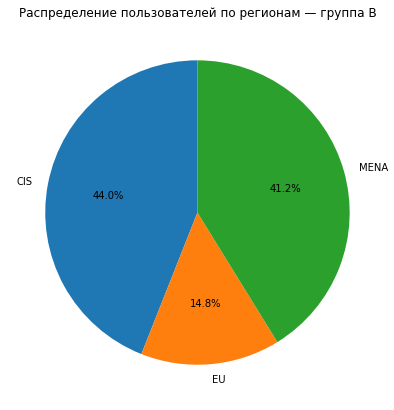

In [33]:
region_b = region_dist[region_dist['test_group'] == 'B']
plt.figure(figsize=(7, 7))
plt.pie(
    region_b['region_ratio'], 
    labels=region_b['region'], 
    autopct='%1.1f%%', 
    startangle=90
)
plt.title('Распределение пользователей по регионам — группа B')
plt.show()

In [34]:
region_distribution = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index()
region_distribution.rename(columns={'user_id': 'users_count'}, inplace=True)

region_distribution['users_ratio'] = region_distribution.groupby('test_group')['users_count'].transform(lambda x: x / x.sum())

display(region_distribution)

,test_group,region,users_count,users_ratio
0,A,CIS,644,0.436019
1,A,EU,224,0.151659
2,A,MENA,609,0.412322
3,B,CIS,645,0.439973
4,B,EU,217,0.148022
5,B,MENA,604,0.412005


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Пользователи распределены почти поровну: в группе A — 1477 человек, в группе B — 1466 человек, разница составляет 0.74%.

Пересечений между группами нет, что подтверждает независимость выборок.

Распределение по устройствам:

Группа A: Android — 656 (44.4%), iPhone — 296 (20.0%), PC — 369 (24.9%), Mac — 156 (10.6%)

Группа B: Android — 668 (45.6%), iPhone — 269 (18.3%), PC — 381 (25.9%), Mac — 148 (10.1%)

Распределение по регионам:

Группа A: CIS — 644 (43.6%), EU — 224 (15.2%), MENA — 609 (41.2%)

Группа B: CIS — 645 (44.0%), EU — 217 (14.8%), MENA — 604 (41.2%)

На основании этих данных можно заключить, что тест проходит корректно: группы сбалансированы, выборки независимы, распределение пользователей по ключевым категориям сходное, нарушений не выявлено.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [35]:
sessions_test_path = '/datasets/sessions_project_test.csv'
sessions_test = pd.read_csv(sessions_test_path)

In [36]:
sessions_test['good_session'] = sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

display(sessions_test.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

In [37]:
# Количество уникальных сессий по дате и группе
daily_sessions = sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().reset_index()
daily_sessions_pivot = daily_sessions.pivot(index='session_date', columns='test_group', values='session_id')

# Группы A и B по числу сессий
sessions_a = daily_sessions_pivot['A']
sessions_b = daily_sessions_pivot['B']

# t-test для независимых выборок
t_stat, p_value = stats.ttest_ind(sessions_a, sessions_b, equal_var=False)

print(f"p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Нет статистически значимого различия между количеством сессий в группах A и B — тест корректен.")
else:
    print("Есть статистически значимое различие между группами — возможно нарушение корректности теста.")


p-value: 0.9382
Нет статистически значимого различия между количеством сессий в группах A и B — тест корректен.


#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [38]:
success_rate = sessions_test.groupby('test_group')['good_session'].mean().reset_index()
success_rate.columns = ['test_group', 'good_session_ratio']

display(success_rate)

,test_group,good_session_ratio
0,A,0.307723
1,B,0.318290


In [39]:
difference = success_rate.loc[success_rate['test_group'] == 'B', 'good_session_ratio'].values[0] - \
             success_rate.loc[success_rate['test_group'] == 'A', 'good_session_ratio'].values[0]
print(f'Разница в доле успешных сессий (B - A): {difference:.4f}')

Разница в доле успешных сессий (B - A): 0.0106


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [40]:
from statsmodels.stats.proportion import proportions_ztest

grouped = sessions_test.groupby('test_group')['good_session'].agg(['sum', 'count']).reset_index()

successes = grouped['sum'].values
nobs = grouped['count'].values

stat, p_value = proportions_ztest(successes, nobs)

print(f"z-статистика: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Разница статистически значима")
else:
    print("Разница не является статистически значимой")


z-статистика: -3.6027
p-value: 0.0003
Разница статистически значима


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Эксперимент был проведён на двух группах пользователей приложения, каждая из которых включала 3761 пользователя. Средний дневной трафик приложения составил 9907 пользователей, что позволило провести тест за 1 день с достаточной статистической мощностью для выявления минимального детектируемого эффекта в 3%.

В качестве ключевой метрики использовалась доля успешных сессий, где успешная сессия определяется как просмотр 4 и более страниц за одну сессию. В контрольной группе A доля успешных сессий составила 30.77%, тогда как в тестовой группе B она выросла до 31.83%, что дало разницу в 1.06%.

Для проверки статистической значимости разницы применялся Z-тест для долей. Результаты показали z = -3.6027 и p-value = 0.0003, что значительно меньше выбранного уровня значимости 0.05, следовательно, улучшение ключевой метрики является статистически значимым.

Таким образом, внедрение нового алгоритма рекомендаций положительно сказывается на вовлечённости пользователей, повышая долю успешных сессий. На основании полученных результатов рекомендуется внедрять новый алгоритм в приложении для всех пользователей.